# Tutorial: CSC1006 Week 9

**Learning goals / 学习目标：**
- Understand binary classification, train/test split, and accuracy. / 理解二分类、训练测试划分和准确率。
- See how kNN, linear classifier, perceptron, and logistic regression behave on runnable examples. / 通过可运行案例理解 kNN、线性分类器、感知机和逻辑回归。
- Compare hard labels and probability outputs, then preview softmax briefly. / 对比硬分类输出与概率输出，并简短预告 softmax。

**Prerequisites / 先修要求：** basic Python, NumPy-style arrays, and simple plots. / 具备基础 Python、数组和简单绘图知识。

**Outline / 目录：**
1. Binary Classification Basics / 二分类基础
2. kNN on Iris (1D) / Iris 上的一维 kNN
3. kNN Decision Boundary (2D) / 二维 kNN 决策边界
4. Linear Classifier + Perceptron / 线性分类器与感知机
5. Logistic Regression / 逻辑回归
6. Short Preview / 简短预告

**Tips:** 在所有代码任务之前，我们都需要先配置好我们所需的环境。我们默认有python的情况下，使用 `pip install` 来下载安装所有我们需要的python库。

当然，如果你使用了anaconda、miniconda等环境管理的软件包，我们也可以使用 `conda install` 来进行下载安装。

Before starting any coding tasks, we need to configure our required environment. If Python is already installed, we'll use `pip install` to download and install all the necessary Python libraries.

Of course, if you're using environment management packages like Anaconda or Miniconda, you can also use `conda install` to download and install them.

In [1]:
!pip install pandas
!pip install pandas
!pip install matplotlib
!pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Jasper\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Jasper\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Jasper\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Jasper\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## Section 0. Imports and Setup / 第0部分：导入与设置

This section prepares the shared libraries, random seed, and plotting helpers. / 这一部分准备公共库、随机种子和绘图辅助函数。

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.datasets import load_iris, make_classification
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier

# 固定随机种子，保证课堂演示结果可重复。
# Fix the random seed so classroom demos stay reproducible.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11


In [3]:
def plot_binary_points(X, y, xlabel, ylabel, title, legend_labels=("Class 0", "Class 1")):
    # 统一二维散点图风格，避免每一节重复写相似代码。
    # Keep a consistent scatter style across sections.
    colors = np.array(["#1f77b4", "#d62728"])
    markers = np.array(["o", "^"])
    plt.figure(figsize=(8, 5))
    for cls in [0, 1]:
        plt.scatter(
            X[y == cls, 0],
            X[y == cls, 1],
            c=colors[cls],
            marker=markers[cls],
            s=55,
            alpha=0.8,
            label=legend_labels[cls],
        )
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.show()


def plot_model_boundary(model, X, y, xlabel, ylabel, title, legend_labels=("Class 0", "Class 1")):
    # 用网格预测结果画出分类区域和决策边界。
    # Predict on a grid to visualize the classification regions.
    colors = np.array(["#1f77b4", "#d62728"])
    markers = np.array(["o", "^"])
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = model.predict(grid).reshape(xx.shape)
    cmap = ListedColormap(["#d8e8ff", "#ffd8d8"])
    plt.figure(figsize=(8, 5))
    plt.contourf(xx, yy, zz, alpha=0.45, cmap=cmap)
    for cls in [0, 1]:
        plt.scatter(
            X[y == cls, 0],
            X[y == cls, 1],
            c=colors[cls],
            marker=markers[cls],
            s=55,
            alpha=0.8,
            label=legend_labels[cls],
        )
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.show()


## Section 1. Binary Classification Basics / 第1部分：二分类基础

A binary classifier receives an input vector and predicts one of two labels. / 二分类模型接收一个输入向量，并预测两个类别中的一个。

We also need a train/test split so we can evaluate on data the model did not see during training. / 我们还需要训练集与测试集划分，这样才能在模型没见过的数据上评估它。

In [4]:
basic_examples = pd.DataFrame(
    {
        "Input x": ["petal width", "study hours", "angle & friction"],
        "Label y": ["virginica or not", "pass or fail", "slide or not slide"],
    }
)
basic_examples


,Input x,Label y
0,petal width,virginica or not
1,study hours,pass or fail
2,angle & friction,slide or not slide


In [5]:
# 这里用一个很小的玩具例子说明 accuracy 的含义。
# This tiny toy example shows what accuracy measures.
y_true = np.array([1, 0, 1, 1, 0, 0])
y_pred = np.array([1, 0, 1, 0, 0, 1])
toy_accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy = {toy_accuracy:.2f}")


Accuracy = 0.67


## Section 2. kNN on Iris (1D) / 第2部分：Iris上的一维kNN

We predict whether a flower is Iris virginica using only petal width. / 我们只用花瓣宽度预测一朵花是否属于 Iris virginica。

In [6]:
iris = load_iris(as_frame=True)
# 只保留一个输入特征 petal width，并把类别改成是否为 virginica 的二分类标签。
# Keep only petal width and convert the target into a binary virginica-vs-not task.
X_iris = iris.data[["petal width (cm)"]].values
y_iris = (iris.target == 2).astype(int).values

X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris,
    y_iris,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y_iris,
)
print("Train size:", X_train_iris.shape[0])
print("Test size :", X_test_iris.shape[0])


Train size: 105
Test size : 45


In [7]:
knn_k1 = KNeighborsClassifier(n_neighbors=1)
# kNN 的“训练”主要是把训练数据记住。
# kNN training mostly means storing the training set.
knn_k1.fit(X_train_iris, y_train_iris)
y_pred_k1 = knn_k1.predict(X_test_iris)
acc_k1 = accuracy_score(y_test_iris, y_pred_k1)
print(f"k=1 accuracy {acc_k1:.3f}")


k=1 accuracy 0.933


In [8]:
# 用交叉验证系统地选择超参数 k，而不是只凭直觉。
# Use cross-validation to choose k systematically instead of guessing.
k_values = list(range(1, 16))
cv_scores = []
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(model, X_train_iris, y_train_iris, cv=5).mean()
    cv_scores.append(score)

best_k = k_values[int(np.argmax(cv_scores))]
print(f"Best k from cross_val_score: {best_k}")


Best k from cross_val_score: 1


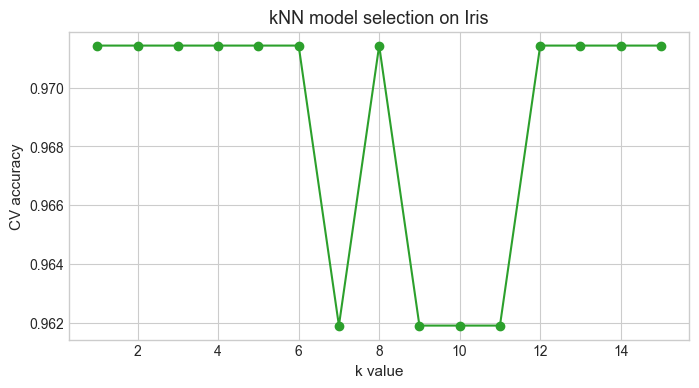

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(k_values, cv_scores, marker="o", color="#2ca02c")
plt.xlabel("k value")
plt.ylabel("CV accuracy")
plt.title("kNN model selection on Iris")
plt.show()


In [10]:
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_iris, y_train_iris)
y_pred_best = knn_best.predict(X_test_iris)
acc_best = accuracy_score(y_test_iris, y_pred_best)
print(f"Best-k accuracy: {acc_best:.3f}")
print(f"Comparison with k=1: {acc_best - acc_k1:+.3f}")


Best-k accuracy: 0.933
Comparison with k=1: +0.000


## Section 3. kNN Decision Boundary (2D) / 第3部分：二维kNN决策边界

Now we move from one feature to two features. / 现在我们从一维特征扩展到二维特征

This section highlights an important point: kNN does not require a linear boundary. / 这一部分强调一个关键点：kNN 不要求决策边界是线性的。

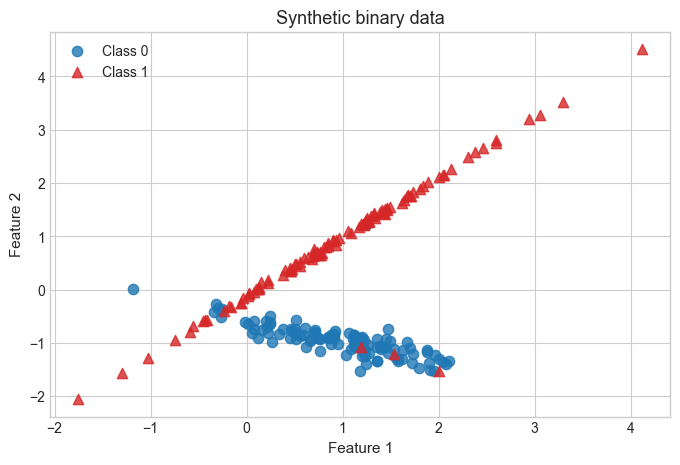

In [11]:
# 生成一个适合课堂可视化的二维二分类数据集。
# Generate a compact 2D dataset that is easy to visualize in class.
X_knn2d, y_knn2d = make_classification(
    n_samples=220,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=1.0,
    flip_y=0.06,
    random_state=RANDOM_STATE,
)
plot_binary_points(
    X_knn2d,
    y_knn2d,
    xlabel="Feature 1",
    ylabel="Feature 2",
    title="Synthetic binary data",
)


In [12]:
X_train_knn2d, X_test_knn2d, y_train_knn2d, y_test_knn2d = train_test_split(
    X_knn2d,
    y_knn2d,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_knn2d,
)

knn2d = KNeighborsClassifier(n_neighbors=7)
knn2d.fit(X_train_knn2d, y_train_knn2d)
y_pred_knn2d = knn2d.predict(X_test_knn2d)
print(f"2D kNN accuracy: {accuracy_score(y_test_knn2d, y_pred_knn2d):.3f}")


2D kNN accuracy: 1.000


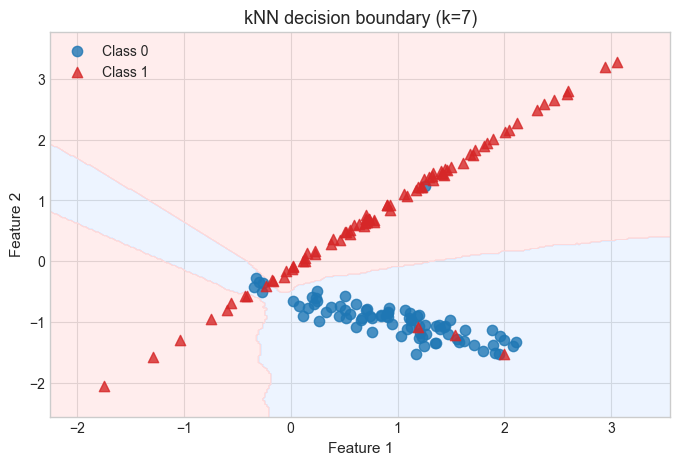

In [13]:
plot_model_boundary(
    knn2d,
    X_train_knn2d,
    y_train_knn2d,
    xlabel="Feature 1",
    ylabel="Feature 2",
    title="kNN decision boundary (k=7)",
)


## Section 4. Linear Classifier + Perceptron / 第4部分：线性分类器与感知机

New case: Study Hours + Attendance -> Pass / Fail. / 新案例：学习时长 + 出勤率 -> 是否通过。

We first build intuition with a hand-crafted linear score, then let the perceptron learn a separating line from data. / 我们先用手工设计的线性打分建立直觉，再让感知机从数据中学习分界线。

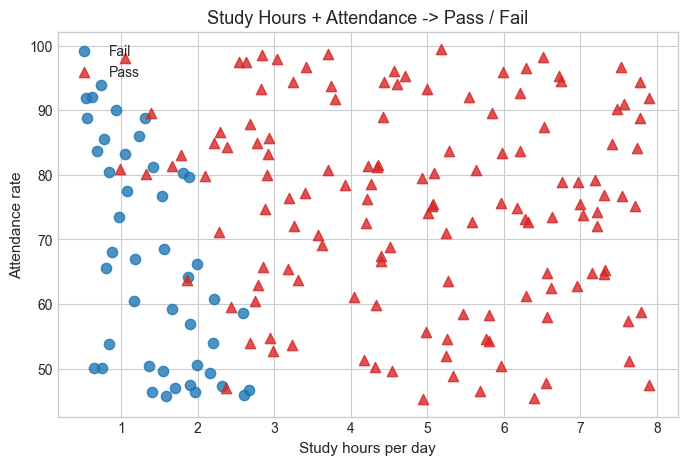

In [14]:
# 构造一个生活化的二维案例，特征是学习时长和出勤率。
# Build a classroom-friendly dataset with study hours and attendance.
n_students = 180
study_hours = np.random.uniform(0.5, 8.0, size=n_students)
attendance = np.random.uniform(45, 100, size=n_students)
linear_score = 1.1 * study_hours + 0.045 * attendance - 5.3
noise = np.random.normal(0, 0.45, size=n_students)
y_student = ((linear_score + noise) > 0).astype(int)
X_student = np.column_stack([study_hours, attendance])

plot_binary_points(
    X_student,
    y_student,
    xlabel="Study hours per day",
    ylabel="Attendance rate",
    title="Study Hours + Attendance -> Pass / Fail",
    legend_labels=("Fail", "Pass"),
)


In [15]:
# 手工定义一个线性分类器，帮助学生理解 w1*x1 + w2*x2 + b 的意义。
# Manually define a linear classifier so students can read w1*x1 + w2*x2 + b directly.
manual_weights = np.array([1.0, 0.05])
manual_bias = -5.0
manual_pred = ((X_student @ manual_weights) + manual_bias >= 0).astype(int)
manual_acc = accuracy_score(y_student, manual_pred)
print(f"Manual linear classifier accuracy: {manual_acc:.3f}")


Manual linear classifier accuracy: 0.900


C:\Users\Jasper\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26410 (\N{CJK UNIFIED IDEOGRAPH-672A}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Jasper\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36890 (\N{CJK UNIFIED IDEOGRAPH-901A}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Jasper\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36807 (\N{CJK UNIFIED IDEOGRAPH-8FC7}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


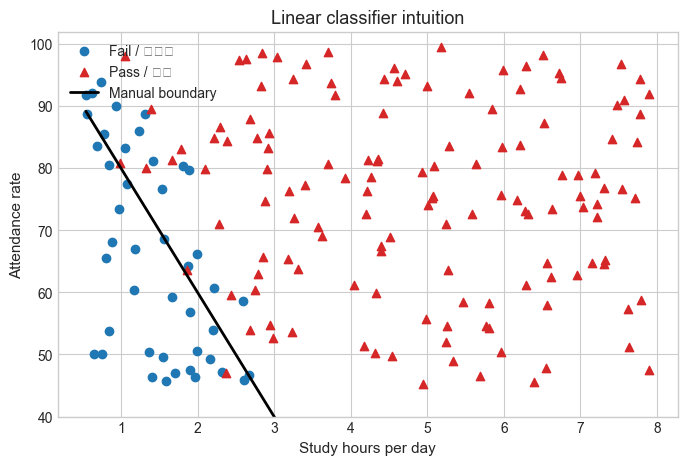

In [16]:
plt.figure(figsize=(8, 5))
plt.scatter(X_student[y_student == 0, 0], X_student[y_student == 0, 1], c="#1f77b4", label="Fail / 未通过")
plt.scatter(X_student[y_student == 1, 0], X_student[y_student == 1, 1], c="#d62728", marker="^", label="Pass / 通过")
x_line = np.linspace(X_student[:, 0].min(), X_student[:, 0].max(), 200)
y_line = -(manual_weights[0] * x_line + manual_bias) / manual_weights[1]
plt.plot(x_line, y_line, color="black", linewidth=2, label="Manual boundary")
plt.xlabel("Study hours per day")
plt.ylabel("Attendance rate")
plt.title("Linear classifier intuition")
plt.legend()
plt.ylim(40, 102)
plt.show()


In [17]:
X_train_student, X_test_student, y_train_student, y_test_student = train_test_split(
    X_student,
    y_student,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_student,
)

perceptron = Perceptron(max_iter=1000, eta0=0.05, random_state=RANDOM_STATE, tol=1e-4)
perceptron.fit(X_train_student, y_train_student)
student_pred = perceptron.predict(X_test_student)
student_acc = accuracy_score(y_test_student, student_pred)
print(f"Perceptron accuracy: {student_acc:.3f}")
print("Weights:", perceptron.coef_[0])
print("Bias:", perceptron.intercept_[0])


Perceptron accuracy: 0.756
Weights: [49.70521722  0.17833689]
Bias: -5.699999999999988


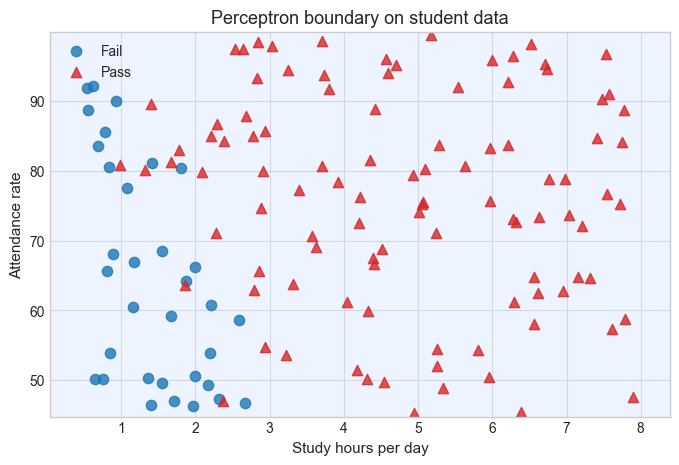

In [18]:
plot_model_boundary(
    perceptron,
    X_train_student,
    y_train_student,
    xlabel="Study hours per day",
    ylabel="Attendance rate",
    title="Perceptron boundary on student data",
    legend_labels=("Fail", "Pass"),
)


### Exercise / 课堂小练习

If a student studies 4.5 hours per day and attends 88% of classes, which side of the boundary do you expect? / 如果一个学生每天学习 4.5 小时、出勤率 88%，你预计他会落在哪一侧？

Try writing a one-line prediction below before running the answer scaffold. / 先自己写一行预测，再运行下面的答案框架。

In [19]:
# Answer scaffold / 参考答案框架
# 先把你的预测写在 expected_label 里，再运行模型检验。
# Write your guess in expected_label, then compare it with the model output.
sample_student = np.array([[4.5, 88.0]])
expected_label = "Pass or Fail?"
model_label = perceptron.predict(sample_student)[0]
print("Your expectation:", expected_label)
print("Model prediction (1=Pass, 0=Fail):", model_label)


Your expectation: Pass or Fail?
Model prediction (1=Pass, 0=Fail): 1


## Section 5. Logistic Regression / 第5部分：逻辑回归

Logistic regression still uses a linear score internally, but its output is a probability between 0 and 1. / 逻辑回归内部依然使用线性打分，但它输出的是 0 到 1 之间的概率。

### Part A: Iris probability curve / 第一部分：Iris 概率曲线

In [20]:
log_reg_iris = LogisticRegression(random_state=RANDOM_STATE)
log_reg_iris.fit(X_train_iris, y_train_iris)

# predict_proba 给出的不是类别编号，而是每一类的概率。
# predict_proba returns class probabilities rather than hard labels.
X_curve = np.linspace(0, 3, 500).reshape(-1, 1)
iris_proba = log_reg_iris.predict_proba(X_curve)
decision_boundary = X_curve[iris_proba[:, 1] >= 0.5][0, 0]
print(f"Decision boundary / 决策边界: {decision_boundary:.2f} cm")


Decision boundary / 决策边界: 1.68 cm


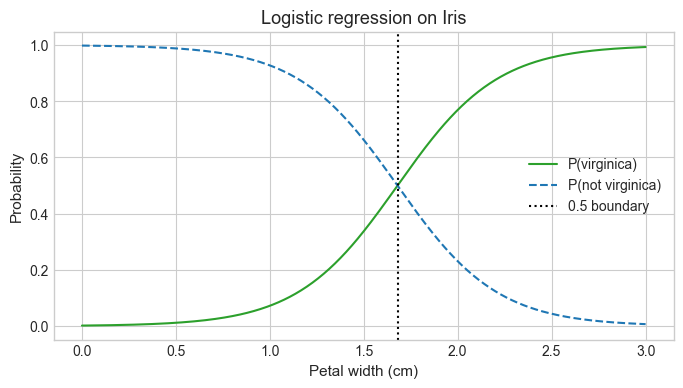

In [21]:
plt.figure(figsize=(8, 4))
plt.plot(X_curve, iris_proba[:, 1], color="#2ca02c", label="P(virginica)")
plt.plot(X_curve, iris_proba[:, 0], color="#1f77b4", linestyle="--", label="P(not virginica)")
plt.axvline(decision_boundary, color="black", linestyle=":", label="0.5 boundary")
plt.xlabel("Petal width (cm)")
plt.ylabel("Probability")
plt.title("Logistic regression on Iris")
plt.legend()
plt.show()


### Part B: Will an object slide on an incline? / 第二部分：物体会不会沿斜面下滑？

Physics case: Will an object slide on an incline? / 物理案例：物体会不会沿斜面下滑？

The two features are angle and friction coefficient. / 这里使用角度和摩擦系数两个特征。

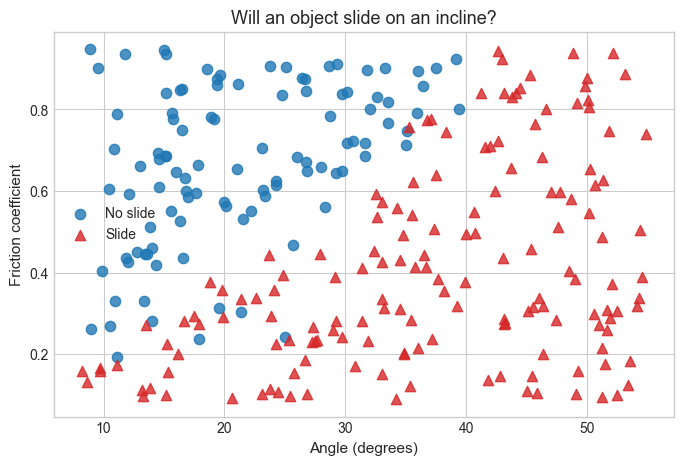

In [22]:
# 根据 tan(theta) 是否大于摩擦系数 mu 来构造“下滑/不下滑”标签，并加入少量噪声。
# Build slide-vs-not labels from tan(theta) and friction, then add a little noise.
n_physics = 260
angle_deg = np.random.uniform(8, 55, size=n_physics)
mu = np.random.uniform(0.08, 0.95, size=n_physics)
physics_margin = np.tan(np.deg2rad(angle_deg)) - mu
physics_noise = np.random.normal(0, 0.08, size=n_physics)
y_slide = ((physics_margin + physics_noise) > 0).astype(int)
X_slide = np.column_stack([angle_deg, mu])

plot_binary_points(
    X_slide,
    y_slide,
    xlabel="Angle (degrees)",
    ylabel="Friction coefficient",
    title="Will an object slide on an incline?",
    legend_labels=("No slide", "Slide"),
)


In [23]:
X_train_slide, X_test_slide, y_train_slide, y_test_slide = train_test_split(
    X_slide,
    y_slide,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_slide,
)

slide_clf = LogisticRegression(random_state=RANDOM_STATE)
slide_clf.fit(X_train_slide, y_train_slide)
slide_pred = slide_clf.predict(X_test_slide)
slide_acc = accuracy_score(y_test_slide, slide_pred)
print(f"Physics logistic accuracy / 物理逻辑回归准确率: {slide_acc:.3f}")


Physics logistic accuracy / 物理逻辑回归准确率: 0.938


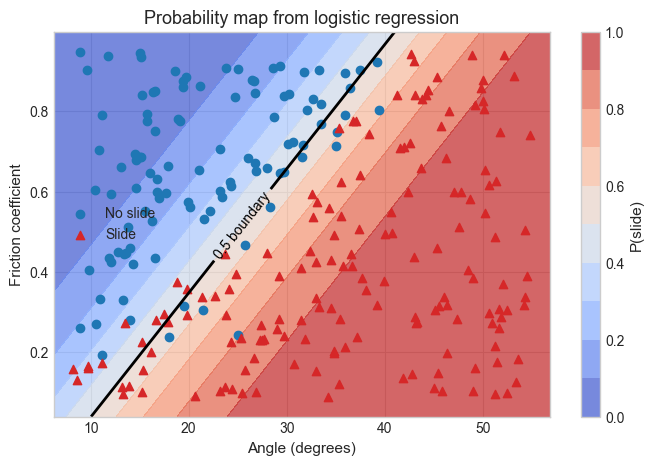

In [24]:
xx, yy = np.meshgrid(
    np.linspace(X_slide[:, 0].min() - 2, X_slide[:, 0].max() + 2, 250),
    np.linspace(X_slide[:, 1].min() - 0.05, X_slide[:, 1].max() + 0.05, 250),
)
physics_grid = np.c_[xx.ravel(), yy.ravel()]
physics_proba = slide_clf.predict_proba(physics_grid)[:, 1].reshape(xx.shape)

plt.figure(figsize=(8, 5))
contour = plt.contourf(xx, yy, physics_proba, levels=np.linspace(0, 1, 11), cmap="coolwarm", alpha=0.75)
plt.colorbar(contour, label="P(slide)")
boundary = plt.contour(xx, yy, physics_proba, levels=[0.5], colors="black", linewidths=2)
plt.clabel(boundary, fmt={0.5: "0.5 boundary"})
plt.scatter(X_slide[y_slide == 0, 0], X_slide[y_slide == 0, 1], c="#1f77b4", label="No slide")
plt.scatter(X_slide[y_slide == 1, 0], X_slide[y_slide == 1, 1], c="#d62728", marker="^", label="Slide")
plt.xlabel("Angle (degrees)")
plt.ylabel("Friction coefficient")
plt.title("Probability map from logistic regression")
plt.legend()
plt.show()


In [25]:
# 看一个具体样本的概率输出，而不是只看 0/1 结果。
# Inspect one concrete sample as a probability, not only as a hard label.
new_object = np.array([[30.0, 0.40]])
slide_probability = slide_clf.predict_proba(new_object)[0, 1]
slide_label = slide_clf.predict(new_object)[0]
print(f"Predicted slide probability / 预测下滑概率: {slide_probability:.3f}")
print(f"Predicted label (1=slide) / 预测标签（1=下滑）: {slide_label}")


Predicted slide probability / 预测下滑概率: 0.788
Predicted label (1=slide) / 预测标签（1=下滑）: 1


## Section 6. Short Preview / 第6部分：简短预告

Softmax preview: logistic regression can be extended from two classes to more than two classes. / Softmax 预告：逻辑回归可以从二分类扩展到多分类。

In [26]:
# 这里用 Iris 的后两个特征做一个极短的 softmax 预告。
# Use the last two Iris features for a very short softmax preview.
X_softmax = iris.data[["petal length (cm)", "petal width (cm)"]].values
y_softmax = iris.target.values
softmax_reg = LogisticRegression(max_iter=200, random_state=RANDOM_STATE)
softmax_reg.fit(X_softmax, y_softmax)
preview_sample = np.array([[5.0, 1.7]])
print("Softmax preview prediction / Softmax预告预测:", softmax_reg.predict(preview_sample)[0])
print("Softmax preview probabilities / Softmax预告概率:", softmax_reg.predict_proba(preview_sample)[0])


Softmax preview prediction / Softmax预告预测: 2
Softmax preview probabilities / Softmax预告概率: [4.91208067e-04 4.01168383e-01 5.98340409e-01]


### Wrap-up / 小结

- kNN stores data and predicts by local neighbors. / kNN 记住数据并通过邻居进行预测。
- A linear classifier uses a weighted sum and a threshold. / 线性分类器使用加权和与阈值。
- Perceptron learns a separating line directly from labels. / 感知机直接从标签中学习分界线。
- Logistic regression adds probabilities on top of a linear score. / 逻辑回归在一个线性得分之上输出概率。